#Step 1: Write your Segmentation Algoirthm

Write a function that segments a leaf image, and returns a binary (`dtype='bool'`) image representing the segmentation.  Your algorithm must be based on thresholding and you should consider doing some region processing after segmentation to improve the result.

_Hint: You'll need to be a bit creative when devising your solution -- no single technique from class is likely to give you a particularly good solution, and you may need to think of some tricks that were not explicitly covered in class.  However, you can get a good result with a fairly simple algorithm.  You'll also need to decide how to handle the fact that the input images are colour, although this shouldn't pose too much of a problem, in fact, it is an advantage!_


In [136]:
import skimage.util as util
import skimage.io as io
import numpy as np
import os as os
import matplotlib.pyplot as plt
import skimage.color as color
import skimage.filters as filt
import skimage.morphology as morph

# You can import other modules as needed.

def segleaf(I):
    '''
    Segment a leaf image.
    :param I: Color leaf image to segment.
    :return: Logical image where True pixels represent foreground (i.e. leaf pixels).
    '''
 
    img = I
    img_red = img[:, :, 0]
    img_green = img[:, :, 1]
    img_blue = img[:, :, 2]
    
    binary = (img_green > img_red) & (img_green > img_blue) & \
             (img_blue < (0.5*255))
    
    img_processed = morph.binary_opening(binary, selem=morph.disk(4))
    img_processed = morph.remove_small_objects(img_processed, min_size=20000)
    img_processed = morph.remove_small_holes(img_processed, min_size=6000)
    img_processed = morph.binary_closing(img_processed, selem=morph.disk(3))
    
    return img_processed


# Step 2: Implment Measures

Write functions to compute the Mean Squared Distance (MSD), Hausdorff Distance (HD) and Dice Similarity Coefficient (DSC) measures of segmentation quality.  

For MSD and HD, I suggest you reprsent boundaries by N-row, 2-column arrays where each row is the coordinate of one pixel on the region's boundary of the form [r,c], row first, then column.

In [137]:
import skimage.segmentation as seg


def calculate_distance(a_vector, g_vector):
    distances = []
    for i in range(0, a_vector.shape[0]):
        a = np.tile(a_vector[i], (g_vector.shape[0], 1))
        distance = np.sqrt(((a-g_vector)**2).sum(axis=1))
        minimum = distance.min()
        distances.append(minimum)
    return distances
    
    
def mean_squared_distance(a_vector, g_vector):
    sum = np.sum(np.array(calculate_distance(a_vector, g_vector))**2)
    avg = sum/a_vector.shape[0]
    return avg


def hausdorff_distance(a_vector, g_vector):
    max1 = (np.max(calculate_distance(a_vector, g_vector)))
    max2 = (np.max(calculate_distance(g_vector, a_vector)))
    return np.max(np.array(max1, max2))


def dice_similarity_coefficient(A, G):
    overlap_region = np.sum((A == 1) & (G == 1))
    a_count = np.count_nonzero(A)
    g_count = np.count_nonzero(G)
    dsc = (2*overlap_region)/(a_count+g_count)
    return dsc


# Step 3: Write a Validation driver program.

Write code that segments each image, and computes the MSD, HD, and DSC for each segmentation.  Print the MSD, HD, and DSC of each segmentation as you perform it.  At the end, print the average and standard deviation of the DSC, the MSD and the HD over all of the images.  Also print the percentage of regions that were "recognized" (see below).  Sample output is in the assignment description document.

The general approach should be, for each input image (in the `images` folder):

* load the image and it's ground truth
* segment the input image - this should be a binary image with a single region (connected component).
* extract the region boundary points from the segmented image and ground truth image; store them in Nx2 arrays as described above (see lecture nodes for an example on how to do this!).
* Compute the MSD and the HD from the two sets of boundary points (using the functions in Step 2).
* Compute the DSC from the segmented image and the ground truth image (using the function from Step 2).
* Determine whether the leaf was "recognized" (a leaf is recognized if it's DSC is greater than 0.6).
* Print the MSD, HD, and DSC to the console (see sample output).

When finished, don't forget to print the average and standard deviation of the DSC for all images, and the percentage of images where the leaf was "recognized".

_Feel free to define additional helper functions for your program if you think it will help._

In [139]:
#### Validate ####

# Paths for folders -- original and ground truth images
images_path = os.path.join('.', 'images')
gt_path = os.path.join('.', 'groundtruth')

DSC = []
MSD = []
HD = []

# Iterate over all files in the original images folder
for root, dirs, files in os.walk(images_path):
    for filename in files:
        # ignore files that are not PNG files.
        if filename[-4:] != '.png':
            continue
            
        # concatenate variable root with filename to get the path to an input file.
        ground_name = os.path.join(gt_path, 'thresh'+filename).replace('\\', '/')
        image_name = os.path.join(images_path, filename).replace('\\', '/')

        img = io.imread(image_name)
        result = segleaf(img)
        result_boundary = np.where(seg.find_boundaries(result > 0, connectivity=2, mode='inner') > 0) 
        result_boundary = np.transpose(np.vstack(result_boundary))
        
        g_img = io.imread(ground_name)
        g_img = g_img == 255
        g_boundary = np.where(seg.find_boundaries(g_img > 0, connectivity=2, mode='inner') > 0) 
        g_boundary = np.transpose(np.vstack(g_boundary))
        
        msd_value = mean_squared_distance(result_boundary, g_boundary)
        hd_value = hausdorff_distance(result_boundary, g_boundary)
        dsc_value = dice_similarity_coefficient(result, g_img)
        
        MSD.append(msd_value)
        HD.append(hd_value)
        DSC.append(dsc_value)
        
        print('DSC for ' + filename + ': ' + str(dsc_value))
        print('MSD for ' + filename + ': ' + str(msd_value))
        print('HD for ' + filename + ': ' + str(hd_value))
        print('--------------------------------------------------')

DSC = np.array(DSC)
MSD = np.array(MSD)
HD = np.array(HD)

print('Mean DSC: ' + str(DSC.mean()))
print('Std. Dev of DSC: ' + str(DSC.std()))
print('Mean MSD: ' + str(MSD.mean()))
print('Std. Dev of MSD: ' + str(MSD.std()))
print('Mean HD: ' + str(HD.mean()))
print('Std. Dev of HD: ' + str(HD.std()))
print(str((np.sum(DSC > 0.9) / len(DSC)) * 100) + '% of leaves were recognized')


C:\Users\Sherry\Anaconda3\lib\site-packages\skimage\morphology\misc.py:207: UserWarning: the min_size argument is deprecated and will be removed in 0.16. Use area_threshold instead.
  "0.16. Use area_threshold instead.")


DSC for image_0001.png: 0.9935068356030872
MSD for image_0001.png: 0.36818732337505045
HD for image_0001.png: 2.8284271247461903
--------------------------------------------------


DSC for image_0002.png: 0.9896836544729927
MSD for image_0002.png: 0.45209947003668977
HD for image_0002.png: 3.1622776601683795
--------------------------------------------------


DSC for image_0005.png: 0.992781956716064
MSD for image_0005.png: 0.5369307309605817
HD for image_0005.png: 5.0
--------------------------------------------------


DSC for image_0007.png: 0.993836653850635
MSD for image_0007.png: 0.4721046556367834
HD for image_0007.png: 4.0
--------------------------------------------------


...

DSC for image_0165.png: 0.989402069438176
MSD for image_0165.png: 1.3724756918474197
HD for image_0165.png: 3.605551275463989
--------------------------------------------------


DSC for image_0166.png: 0.9867858189276296
MSD for image_0166.png: 3.063917525773196
HD for image_0166.png: 9.486832980505138
--------------------------------------------------


DSC for image_0171.png: 0.9852116944691239
MSD for image_0171.png: 2.7169948942377826
HD for image_0171.png: 7.211102550927978
--------------------------------------------------


DSC for image_0174.png: 0.9817413212300782
MSD for image_0174.png: 9.418495297805643
HD for image_0174.png: 18.681541692269406
--------------------------------------------------


DSC for image_0175.png: 0.9887917252705973
MSD for image_0175.png: 1.894414690130069
HD for image_0175.png: 7.211102550927978
--------------------------------------------------
Mean DSC: 0.9895934686639353
Std. Dev of DSC: 0.00402962230498431
Mean MSD: 2.304648325313211
Std. Dev of MSD: 3.3422178066248653
Mean HD: 6.399930786030126
Std. Dev of HD: 5.273286698131489
100.0% of leaves were recognized


# Step 4:  Display Examples

Choose one input image where your algoirthm performed very well.  Choose another image where the algorithm did not perform well.  Display the two original images with the segmentation superimposed on top (There is an example in the lecture notes -- last slide, Topic 6 -- showing how to do this).  Also display the same two image's ground truth with the segmentation superimposed on top.    Title the images to indicate which is the "good" example, and which is the "bad" example.


C:\Users\Sherry\Anaconda3\lib\site-packages\skimage\morphology\misc.py:207: UserWarning: the min_size argument is deprecated and will be removed in 0.16. Use area_threshold instead.
  "0.16. Use area_threshold instead.")


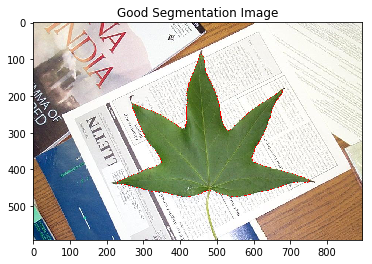

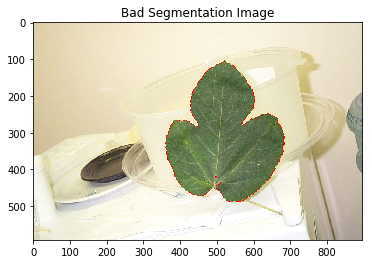

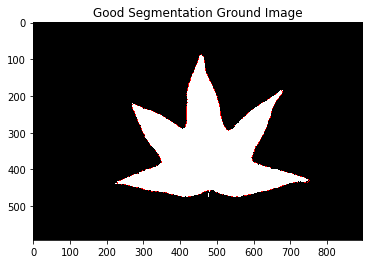

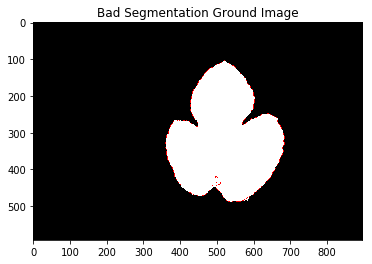

In [135]:
import matplotlib.pyplot as plt

% matplotlib inline

good_img = io.imread('images/image_0010.png')
good_binary = segleaf(good_img)
good_L = morph.label(good_binary, connectivity=2)
boundaries = seg.find_boundaries(good_L, connectivity=2, mode='inner') 
good_img = seg.mark_boundaries(good_img, good_L, color=(1,0,0))

bad_img = io.imread('images/image_0078.png')
bad_binary = segleaf(bad_img)
bad_L = morph.label(bad_binary, connectivity=2)
boundaries = seg.find_boundaries(bad_L, connectivity=2, mode='inner') 
bad_img = seg.mark_boundaries(bad_img, bad_L, color=(1,0,0))

good_ground = io.imread('groundtruth/threshimage_0010.png')
good_ground = seg.mark_boundaries(good_ground, good_L, color=(1,0,0))

bad_ground = io.imread('groundtruth/threshimage_0078.png')
bad_ground = seg.mark_boundaries(bad_ground, bad_L, color=(1,0,0))

plt.imshow(good_img)
plt.title('Good Segmentation Image')
plt.show()
plt.imshow(bad_img)
plt.title('Bad Segmentation Image')
plt.show()

plt.imshow(good_ground)
plt.title('Good Segmentation Ground Image')
plt.show()
plt.imshow(bad_ground)
plt.title('Bad Segmentation Ground Image')
plt.show()





# Step 5: A time for reflection.

### Answer the following questions right here in this block.

1. In a few sentences, briefly explain what your segmentation algorithm from Step 1 does and how it works.  

	_Your answer:_  The algorithm compares the colour channels to each other and thresholds the images by the amount of green (because the leaves are green). Afterwards it does some region processing, like using the opening method to reduce the background structures, selecting for the leaf by removing small objects, removing small holes in the leaves and finally closing to fill some gaps in the leaves where the stems were.

2. Consider your good result.  What, if anything, about your algoirthm is preventing you from getting a better result with this image?  If you weren't able to get any results, leave this blank, or explain what was preventing you from getting a result.

	_Your answer:_  The difference between the segmentation by the algorithm and the ground image is that the ground image has more defined edges and also the ground image has a bit of the stem left so some region overlap is missing. The edges are more deteriorated by the segmentation algorithm by the opening method so to get a better result that would require more modification of the opening method's parameters. The radius of the structuring element was set higher for better segmentation of a different image.

3. Consider your bad result.  What is it about your algoirthm caused the poor performance?   If you weren't able to get any results, leave this blank.

	_Your answer:_ The removal of thin structures in the image by the opening method got rid of the veins in the leaf and through filling of the holes and gaps, the part where all the veins of the leaves connect wasn't filled enough, therefore still leaving some gaps that causes a high MSD. This could be improved on by diluting or closing the image more.
